# Hilbert Vibration Decomposition (HVD)

**HVD** (Feldman, 2006) decomposes a non-stationary multi-component vibration
into simple quasi-harmonic modes ordered by **decreasing amplitude**, using
only the Hilbert transform / analytic signal — no spline envelopes as in EMD.

$$
x(t)=\sum_{\ell} a_\ell(t)\,\cos\!\Big(\int \omega_\ell(t)\,dt\Big).
$$

**Reference**

> M. Feldman.  
> *Time-varying vibration decomposition and analysis based on the Hilbert transform.*  
> Journal of Sound and Vibration, 295(3–5):518–530, 2006.

This notebook uses `pysdkit.HVD` and reproduces the spirit of the paper’s
simulation examples (Sec. 5).

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from pysdkit import HVD
from pysdkit.plot import plot_IMFs

print(HVD())

Hilbert Vibration Decomposition (HVD)


## 2. Algorithm principles (paper §§2–4)

### 2.1 Analytic signal

For a real record $x(t)$, form $X(t)=x(t)+i\,\tilde{x}(t)$ with Hilbert
transform $\tilde{x}$.  Instantaneous amplitude and frequency are

$$
A(t)=|X(t)|,\qquad
\omega(t)=\frac{d}{dt}\arg X(t).
$$

### 2.2 Key property of a two-tone mixture

If $a_1>a_2$, the IF of $a_1 e^{i\int\omega_1}+a_2 e^{i\int\omega_2}$
oscillates about $\omega_1$.  Averaging / low-pass filtering that IF
**cancels the rapid beat** and leaves $\langle\omega(t)\rangle\approx\omega_1$
(paper Eqs. 2–3).  Hence the **largest-energy** carrier is read from the
smoothed IF.

### 2.3 Synchronous demodulation

With estimated carrier $\hat{\omega}_1$, mix and low-pass:

$$
x(t)\,e^{-i\hat{\omega}_1 t}\;\xrightarrow{\;\mathrm{LPF}\;}
\tfrac{a_1}{2}e^{i\phi_1},
$$

recover envelope and phase, rebuild the mode, subtract it, and iterate on the
residual (always peeling the current strongest component).

### 2.4 PySDKit parameters

| Parameter | Role |
| --- | --- |
| `K` | number of modes |
| `fpar` | LPF cut-off in **FFT bins** (paper’s “cut-off frequency”) |
| `mirror` | mirror-pad to reduce end effects |

## 3. Warm-up: two quasi-harmonics (amplitude ordering)

A controlled mixture with $a_1>a_2$ should extract the 40 Hz tone first.

carriers [Hz]: [39.99999996 12.00000332]
relative recon error: 0.010722254771964822


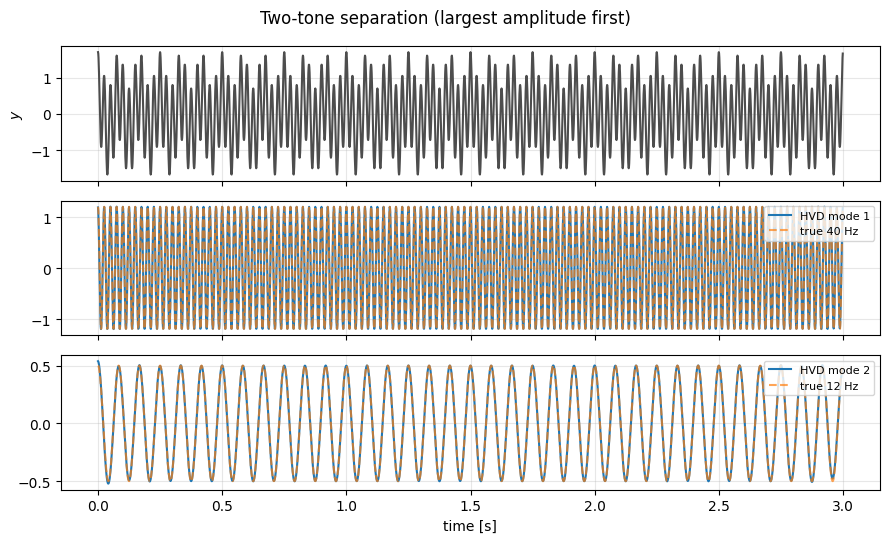

In [2]:
fs = 1000.0
n = 3000
t = np.arange(n) / fs
s1 = 1.2 * np.cos(2 * np.pi * 40 * t)
s2 = 0.5 * np.cos(2 * np.pi * 12 * t)
y = s1 + s2

hvd = HVD(K=2, fpar=40, mirror=True)
imfs, freqs = hvd.fit_transform(y, return_all=True)
print("carriers [Hz]:", freqs * fs)
print("relative recon error:", np.linalg.norm(imfs.sum(0) - y) / np.linalg.norm(y))

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t, y, color="0.3")
axes[0].set_ylabel("$y$")
axes[1].plot(t, imfs[0], label="HVD mode 1")
axes[1].plot(t, s1, "--", alpha=0.7, label="true 40 Hz")
axes[1].legend(loc="upper right", fontsize=8)
axes[2].plot(t, imfs[1], label="HVD mode 2")
axes[2].plot(t, s2, "--", alpha=0.7, label="true 12 Hz")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_xlabel("time [s]")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle("Two-tone separation (largest amplitude first)")
plt.tight_layout()
plt.show()

### Instantaneous frequency of the mixture

Illustrates paper Eq. (2): the IF oscillates, but its low-pass average tracks
the stronger carrier.

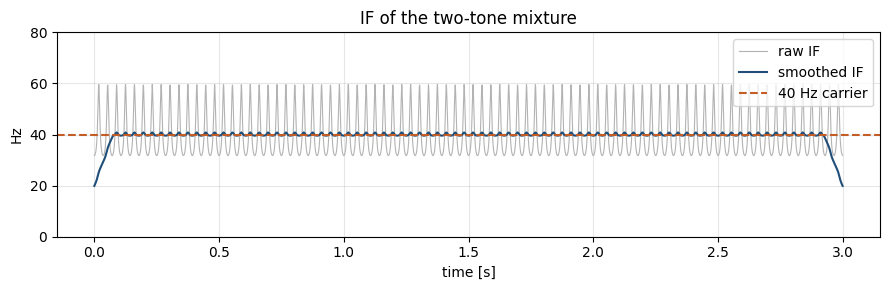

In [3]:
analytic = hilbert(y)
phase = np.unwrap(np.angle(analytic))
inst_f = np.gradient(phase) * fs / (2 * np.pi)

# crude moving average ≈ LPF of the IF
win = 151
kernel = np.ones(win) / win
inst_f_smooth = np.convolve(inst_f, kernel, mode="same")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, inst_f, color="0.7", lw=0.8, label="raw IF")
ax.plot(t, inst_f_smooth, color="#1f4e79", label="smoothed IF")
ax.axhline(40, color="#c45c26", ls="--", label="40 Hz carrier")
ax.set_ylim(0, 80)
ax.set_xlabel("time [s]")
ax.set_ylabel("Hz")
ax.legend(loc="upper right")
ax.set_title("IF of the two-tone mixture")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Paper example — non-stationary square wave (Sec. 5.1)

$$
x(k)=(1+0.003k)\,\mathrm{sgn}\big[\sin((0.02+3\cdot10^{-5}k)\,k)\big],
\quad k=0,\ldots,2047.
$$

Amplitude grows linearly; instantaneous period shortens.  The paper uses a
low-pass cut-off near the lowest frequency $0.02$ and shows the first five
quasi-harmonic terms.

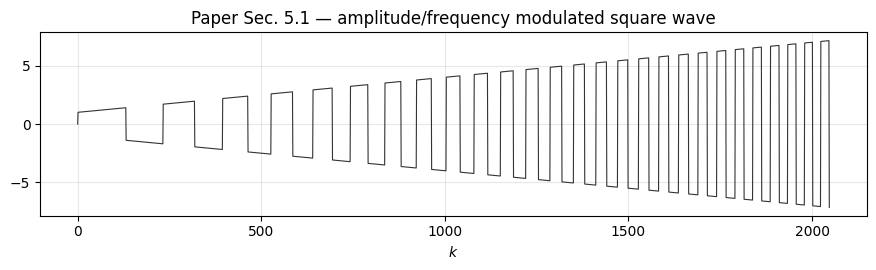

In [4]:
N = 2048
k = np.arange(N, dtype=float)
x = (1.0 + 0.003 * k) * np.sign(np.sin((0.02 + 3.0e-5 * k) * k))

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(k, x, color="0.2", lw=0.8)
ax.set_xlabel("$k$")
ax.set_title("Paper Sec. 5.1 — amplitude/frequency modulated square wave")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modes: (5, 2048)
relative recon error: 0.3159921680501342


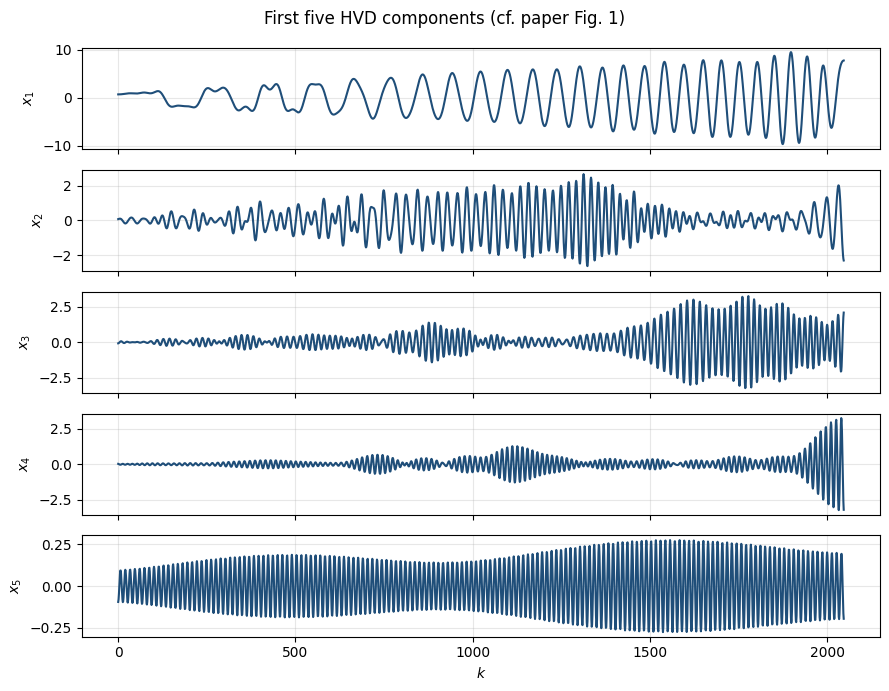

In [5]:
# Cut-off ~ 0.02 rad/sample → ~ 0.02/(2π)·N_fft bins (with mirroring ~2N)
hvd_sq = HVD(K=5, fpar=50, mirror=True)
modes = hvd_sq.fit_transform(x)
print("modes:", modes.shape)
print("relative recon error:", np.linalg.norm(modes.sum(0) - x) / np.linalg.norm(x))

fig, axes = plt.subplots(5, 1, figsize=(9, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(k, modes[i], color="#1f4e79")
    ax.set_ylabel(f"$x_{{{i+1}}}$")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("$k$")
plt.suptitle("First five HVD components (cf. paper Fig. 1)")
plt.tight_layout()
plt.show()

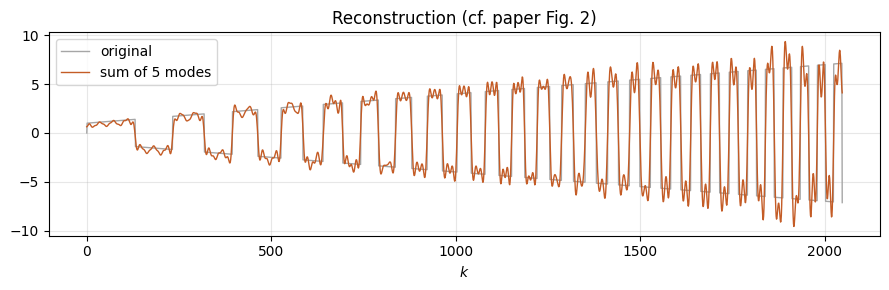

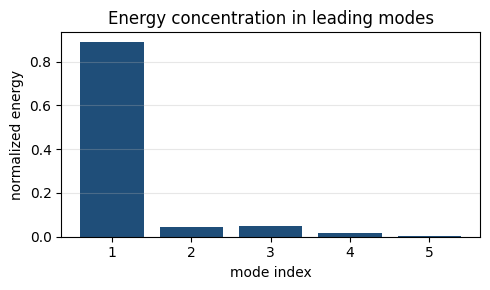

In [6]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(k, x, color="0.65", lw=1.0, label="original")
ax.plot(k, modes.sum(0), color="#c45c26", lw=1.0, label="sum of 5 modes")
ax.legend(loc="upper left")
ax.set_xlabel("$k$")
ax.set_title("Reconstruction (cf. paper Fig. 2)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

energies = np.sum(modes**2, axis=1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(np.arange(1, 6), energies / energies.sum(), color="#1f4e79")
ax.set_xlabel("mode index")
ax.set_ylabel("normalized energy")
ax.set_title("Energy concentration in leading modes")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Chirp-forced linear oscillator (Sec. 5.2, simplified)

The paper integrates $\ddot{x}+0.07\dot{x}+x=\cos(6.5\cdot10^{-5}t^2)$ and
separates **steady-state** vs **transient** free vibration.  Here we synthesize
an analogous beating mixture: a chirp drive plus a decaying natural mode.

carriers [Hz]: [0.02499979 0.02499822]


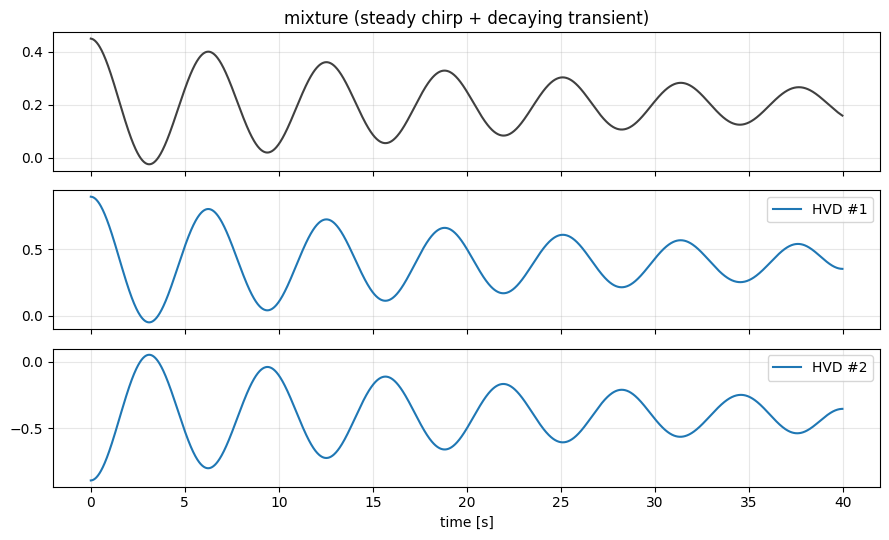

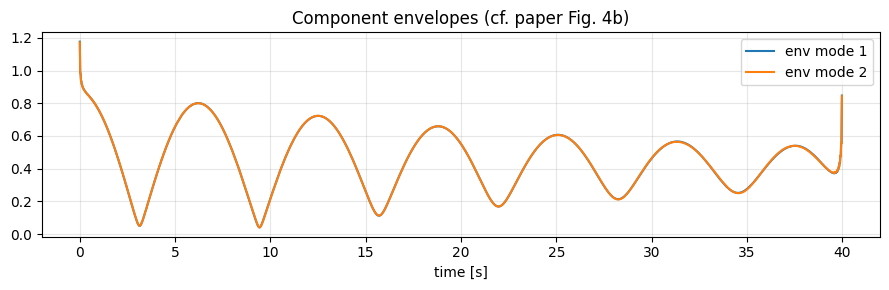

In [7]:
fs2 = 50.0
t2 = np.arange(0, 40, 1 / fs2)
# natural mode ~ 1/(2π) Hz ≈ 0.159 Hz, decaying
wn = 1.0  # rad/s
transient = 0.25 * np.exp(-0.035 * t2) * np.cos(wn * t2)
# chirp excitation response (growing instantaneous frequency)
phase_c = 0.5 * 6.5e-5 * t2**2  # ∫ α t dt with α = 6.5e-5
steady = 0.2 * np.cos(phase_c)
y2 = steady + transient

hvd2 = HVD(K=2, fpar=25, mirror=True)
m2, f2 = hvd2.fit_transform(y2, return_all=True)
print("carriers [Hz]:", f2 * fs2)

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t2, y2, color="0.25")
axes[0].set_title("mixture (steady chirp + decaying transient)")
axes[1].plot(t2, m2[0], label="HVD #1")
axes[1].legend(loc="upper right")
axes[2].plot(t2, m2[1], label="HVD #2")
axes[2].legend(loc="upper right")
axes[2].set_xlabel("time [s]")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# envelopes of separated modes
env0 = np.abs(hilbert(m2[0]))
env1 = np.abs(hilbert(m2[1]))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t2, env0, label="env mode 1")
ax.plot(t2, env1, label="env mode 2")
ax.legend()
ax.set_xlabel("time [s]")
ax.set_title("Component envelopes (cf. paper Fig. 4b)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. API summary

```python
from pysdkit import HVD

hvd = HVD(K=3, fpar=20, mirror=True)
IMFs = hvd.fit_transform(signal)             # (K, N)
IMFs, freqs = hvd.fit_transform(signal, return_all=True)
# freqs are in cycles per sample; Hz = freqs * fs
```

## 7. Takeaways

- HVD peels modes by **amplitude rank**, not by highest frequency (contrast EMD).
- The engine is **smoothed IF + coherent demodulation** of the analytic signal.
- Choose `fpar` from the slowest IF variation you want to keep; too small
  underfits the carrier, too large lets beat frequencies through.
- Best suited to **narrowband / quasi-harmonic** vibration components.